# Theme Worlds — Seamless Wrap-Around Panoramas with MultiDiffusion

<div align=center>

[KAIST AIC.20000: Introduction to AI Computing (Fall 2026)](https://intro-aic.kaist.ac.kr/)

Mini-Project — Visual Content Contest

**Marlen Melis**

</div>

---

## What this notebook makes

Pick one or two **themes** from a 50-entry menu, run one cell, and get a wide
panorama of that world whose **left and right edges join perfectly** — roll the
image sideways by any amount and there is no seam. Two themes produce a single
world that travels from one biome into the other and back again as you go
around the loop.

Everything here is **inference-time only**: no training, no fine-tuning, and
**zero source images**. Every pixel comes from the original Stable Diffusion
v1.5 weights.

## The problem this solves

SD v1.5 was trained at 512x512. Ask it directly for a 2048x512 image and it
does not paint a wide scene — it paints four 512-ish scenes glued together,
with duplicated skylines and warped geometry, because nothing in its training
distribution is that shape.

**MultiDiffusion** ([Bar-Tal et al., 2023](https://arxiv.org/abs/2302.08113))
fixes this without touching the weights. It keeps one shared latent canvas,
crops overlapping 512x512 windows out of it, runs one ordinary SD v1.5 denoising
step on each window, and averages the results back into the canvas at every
step. Each window is a problem the model was trained to solve; the averaging is
what makes them agree with their neighbours.

Two things are built on top of that in this notebook:

1. **Circular windows.** Windows that run off the right edge wrap onto the left
   edge, so the two ends of the canvas are denoised *together* from the first
   step. The panorama loops.
2. **Region-conditioned windows.** Each window gets its own text conditioning.
   With two themes, the conditioning slides smoothly around the loop from one
   theme to the other, so the themes occupy *places* in the world instead of
   fighting for every pixel. This is the region-based branch of the same
   MultiDiffusion formulation (paper, Sec. 4.2).

The sampler is written out in full in Step 5 — it is not a library call.

## Rules compliance, up front

| Rule | How this notebook satisfies it |
| --- | --- |
| Only SD v1.5 may generate pixels | Single checkpoint `stable-diffusion-v1-5/stable-diffusion-v1-5`, printed at load time. MultiDiffusion is a *sampling schedule*, not a model — it introduces no new weights. |
| No third-party SD checkpoints / LoRAs / SDXL / FLUX | None loaded. The only other pretrained weight is CLIP ViT-L/14 (Step 9), used **only to score finished images**, never to generate — the allowed "pretrained reward model" carve-out. It can be switched off. |
| Up to 10 source images | **Zero used.** There is no image input anywhere in this notebook. |
| Runs on a Colab T4 | Yes; fp16, windowed UNet calls (never larger than 64x64 latents), tiled VAE fallback. |
| Reproducible | Every seed is fixed and logged; initial noise is drawn on the **CPU** generator, so the same seed gives the same image on any GPU. |
| No editing outside the notebook | All compositing and labelling are done here with PIL/NumPy. |
| No legible text from the model | SD v1.5 cannot render text. Every label in every figure is drawn by PIL *on top of* finished pixels. |
| Output is a static image | PNG only — no video, no animation, no GIF. |

## Step 1: Environment

This notebook is written for **Google Colab** and runs there end to end, top to
bottom, on the free tier.

Before anything else: `Runtime` -> `Change runtime type` -> **T4 GPU**. The cell
below reports the card you actually got; if it says no GPU, fix the runtime type
and re-run it, because on CPU a single panorama takes hours instead of minutes.

Then `Runtime` -> `Run all`, or just work down the notebook a cell at a time.
The only cell you ever need to edit is Step 6.

In [1]:
import os

import torch

# True on a Google Colab VM.  /var/colab/hostname is the file google.colab's own
# drive.mount() looks for, so it is the reliable signal; "does `google.colab`
# import" is not, because that package turns up in other environments too.
IN_COLAB = os.path.exists("/var/colab/hostname")

print(f"Google Colab  : {IN_COLAB}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        total = torch.cuda.get_device_properties(i).total_memory / 1e9
        print(f"  GPU {i}: {torch.cuda.get_device_name(i)}  ({total:.0f} GB)")
else:
    print("  !! No GPU attached.  Runtime -> Change runtime type -> T4 GPU,")
    print("     then re-run this cell.  On CPU a single panorama takes hours.")

Google Colab  : True
CUDA available: True
  GPU 0: Tesla T4  (16 GB)


In [2]:
# diffusers is not part of the Colab image, so it always installs.  Nothing else
# is touched here: everything this notebook needs beyond diffusers (torch,
# transformers, accelerate, PIL, numpy) already ships with Colab.
%pip install -qqU diffusers safetensors

In [3]:
# `transformers` and `accelerate` come with the Colab image and are normally new
# enough for diffusers.  Force-upgrading them mid-session pulls a fresh
# dependency set underneath modules Colab has already imported, which is the
# usual cause of mysterious import errors further down a notebook -- so only
# touch them if they are genuinely too old.
import importlib.metadata as importlib_metadata
import subprocess
import sys


def _version_tuple(text):
    return tuple(int(part) for part in text.split(".")[:3] if part.isdigit())


def _too_old(package, floor):
    try:
        return _version_tuple(importlib_metadata.version(package)) < _version_tuple(floor)
    except importlib_metadata.PackageNotFoundError:
        return True


stale = [pkg for pkg, floor in (("transformers", "4.41.0"), ("accelerate", "0.31.0"))
         if _too_old(pkg, floor)]
if stale:
    print("upgrading:", ", ".join(stale))
    subprocess.run([sys.executable, "-m", "pip", "install", "-qqU", *stale], check=True)
    print("\n!! Packages that Colab had already loaded were replaced.")
    print("   Runtime -> Restart session, then run from the top again.")
    print("   Nothing has been downloaded or generated yet, so nothing is lost.")
else:
    print("transformers / accelerate already recent enough -- left untouched")

transformers / accelerate already recent enough -- left untouched


In [4]:
import diffusers, transformers
print("diffusers   ", diffusers.__version__)
print("transformers", transformers.__version__)
print("torch       ", torch.__version__)

# StableDiffusionPanoramaPipeline is diffusers' own MultiDiffusion reference
# implementation.  This notebook does NOT depend on it -- the sampler in Step 5
# is written from scratch -- but Step 10 cross-checks against it when it is
# importable, so probe for it here rather than crashing later.
try:
    from diffusers import StableDiffusionPanoramaPipeline
    REFERENCE_PIPELINE_AVAILABLE = True
    print("reference StableDiffusionPanoramaPipeline: available "
          f"({StableDiffusionPanoramaPipeline.__module__.split('.')[-2]})")
except ImportError:
    REFERENCE_PIPELINE_AVAILABLE = False
    print("reference StableDiffusionPanoramaPipeline: not in this diffusers "
          "build -- the optional cross-check in Step 10 will be skipped.")

diffusers    0.40.0
transformers 5.16.1
torch        2.11.0+cu128
reference StableDiffusionPanoramaPipeline: available (stable_diffusion_panorama)


## Step 2: Where your files are saved

There is no dataset to upload — this project uses zero source images — but the
generated panoramas need somewhere to live that outlives the session.

The cell below mounts your Google Drive and writes everything to
`MyDrive/AIC200-ThemeWorlds`, so the images are still there after the runtime
recycles. Colab asks you to authorise the mount once per session.

Set `USE_DRIVE = False` if you would rather not mount Drive. Files then go to
`/content/AIC200-ThemeWorlds` on the VM's own disk, which is **wiped when the
session ends** — grab them from the folder icon in the left sidebar, or run
Step 13 to download everything as one zip, before you close the tab.

In [5]:
from pathlib import Path

USE_DRIVE = True     # False -> keep files on the VM only (lost when it recycles)

PROJECT_DIR = None
if IN_COLAB and USE_DRIVE:
    try:
        from google.colab import drive
        drive.mount("/content/drive")
        # TODO: change only this if you want another folder in My Drive.
        PROJECT_DIR = Path("/content/drive/MyDrive/AIC200-ThemeWorlds")
    except Exception as exc:  # noqa: BLE001
        # Some Colab-flavoured runtimes (local runtime, Colab Enterprise) cannot
        # mount Drive.  Losing Drive is not worth losing the run over.
        print(f"Drive not mountable ({type(exc).__name__}) -- using local disk instead.")
if PROJECT_DIR is None:
    PROJECT_DIR = (Path("/content/AIC200-ThemeWorlds") if IN_COLAB
                   else Path("./AIC200-ThemeWorlds").resolve())

ON_DRIVE     = "drive/MyDrive" in PROJECT_DIR.as_posix()
OUTPUT_DIR   = PROJECT_DIR / "outputs"
METADATA_DIR = PROJECT_DIR / "metadata"
for directory in (OUTPUT_DIR, METADATA_DIR):
    directory.mkdir(parents=True, exist_ok=True)

print(f"Panoramas:    {OUTPUT_DIR}")
print(f"Run metadata: {METADATA_DIR}")
if ON_DRIVE:
    print("\nSaved straight to Google Drive -- they survive the runtime resetting.")
else:
    print("\nThese live on the runtime's own disk, which is cleared when the session\n"
          "ends.  Run Step 13 to bundle them for download before you leave.")

Mounted at /content/drive
Panoramas:    /content/drive/MyDrive/AIC200-ThemeWorlds/outputs
Run metadata: /content/drive/MyDrive/AIC200-ThemeWorlds/metadata

Saved straight to Google Drive -- they survive the runtime resetting.


## Step 3: Load Stable Diffusion v1.5

Two things worth flagging here.

**The checkpoint trap.** The `diffusers` documentation for its panorama
pipeline uses `stabilityai/stable-diffusion-2-base` in the example code. That is
**SD 2**, which is not allowed for this project. Every `from_pretrained` call in
this notebook — the pipeline *and* the scheduler — points at the SD v1.5 repo,
and the id is printed below so it is visible in the saved outputs.

**Why DDIM.** MultiDiffusion calls `scheduler.step()` once per window per
timestep, out of order. `DDIMScheduler` is deterministic and carries no state
between calls, so this is safe; a stateful scheduler (PNDM, which is SD v1.5's
default) would silently corrupt its own history. The cell below swaps it and
asserts the swap took.

The safety checker is not loaded: it is a separate CLIP-based classifier that
costs ~1.2 GB of VRAM, plays no part in generation, and returns a black image
on false positives — which for stylised landscape art is a real risk with no
upside. No people are generated by any prompt in the menu.

In [6]:
import gc
from diffusers import StableDiffusionPipeline, DDIMScheduler

MODEL_ID = "stable-diffusion-v1-5/stable-diffusion-v1-5"   # NOT sd-2-base
DTYPE = torch.float16 if torch.cuda.is_available() else torch.float32
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

_load_kwargs = dict(scheduler=DDIMScheduler.from_pretrained(MODEL_ID,
                                                            subfolder="scheduler"),
                    torch_dtype=DTYPE, safety_checker=None,
                    requires_safety_checker=False)
try:
    # The repo ships fp16 copies of the same weights: half the download and half
    # the VRAM, which is what makes a 16 GB T4 comfortable here.
    pipe = StableDiffusionPipeline.from_pretrained(
        MODEL_ID, variant="fp16" if DTYPE == torch.float16 else None,
        **_load_kwargs)
except (OSError, ValueError) as exc:  # noqa: BLE001
    # Only reachable if the fp16 files ever disappear from the repo; the fp32
    # ones are cast on load and give identical results, just slower to fetch.
    print(f"fp16 variant unavailable ({type(exc).__name__}) -- using default weights.")
    pipe = StableDiffusionPipeline.from_pretrained(MODEL_ID, **_load_kwargs)

pipe = pipe.to(DEVICE)
pipe.set_progress_bar_config(disable=True)
pipe.unet.eval(); pipe.vae.eval(); pipe.text_encoder.eval()

assert isinstance(pipe.scheduler, DDIMScheduler), "MultiDiffusion needs DDIM here"
print(f"Checkpoint : {MODEL_ID}")
print(f"Device     : {DEVICE}  ({DTYPE})")
print(f"Scheduler  : {type(pipe.scheduler).__name__}, "
      f"prediction_type={pipe.scheduler.config.prediction_type}")
print(f"UNet params: {sum(p.numel() for p in pipe.unet.parameters())/1e6:.0f}M")

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


/usr/local/lib/python3.13/dist-packages/diffusers/utils/deprecation_utils.py:23: FutureWarning: `torch_dtype` is deprecated and will be removed in version 1.0.0. Please use `dtype` instead.
  deprecate("torch_dtype", "1.0.0", _TORCH_DTYPE_DEPRECATION_MESSAGE)


Checkpoint : stable-diffusion-v1-5/stable-diffusion-v1-5
Device     : cuda  (torch.float16)
Scheduler  : DDIMScheduler, prediction_type=epsilon
UNet params: 860M


## Step 4: The theme menu

Fifty worlds to choose from. Nothing here runs automatically — the notebook
only ever generates the theme(s) picked in Step 6.

Each entry is a *scene description*, deliberately written without any
"object A next to object B" spatial demands. SD v1.5's model card is explicit
that precise multi-object compositionality is one of its weak points; wide
environment scenes are the genre where that weakness costs the least.

In [7]:
THEME_PROMPTS = {
    "fantasy": "floating islands with ancient stone ruins drifting above a sea of clouds, "
               "waterfalls pouring off the edges, golden hour light, matte painting",
    "dragon_spire": "towering dragon-carved spires rising from misty mountain peaks, ancient "
                    "stone bridges between the towers, dragons circling in the distance",
    "enchanted_forest": "a glowing enchanted forest at twilight, giant luminous mushrooms, "
                        "fireflies drifting through the air, moss-covered ancient trees, magical "
                        "mist",
    "crystal_cavern": "a vast underground cavern filled with towering glowing crystals, "
                      "reflective still water pools, soft blue and violet light",
    "sky_temple": "an ornate temple floating among the clouds, golden domes and carved stone "
                  "pillars, stairways leading into open sky, serene light",
    "giant_tree_civilization": "a civilization built into the trunk and branches of an impossibly "
                               "massive ancient tree, wooden bridges, lantern-lit windows, misty "
                               "forest floor below",
    "dune_sea_world": "an endless golden dune sea beneath twin suns, wind-carved sand ridges, a "
                      "distant caravan silhouette, epic desert fantasy",
    "cyberpunk": "neon-lit megacity skyline at night, rain-slicked rooftops, glowing signage "
                 "reflections, purple and cyan lighting, dense skyscrapers",
    "cloud_city": "a futuristic city built on massive platforms suspended high above the clouds, "
                  "sleek towers, aerial walkways, soft golden haze",
    "derelict_spaceship": "the vast interior of an abandoned spaceship hangar, rusted metal "
                          "walkways, flickering emergency lights, starlight through a cracked "
                          "hull breach",
    "solarpunk_city": "a green utopian city where futuristic architecture is covered in lush "
                      "plant life, solar panels, elevated gardens, bright optimistic daylight",
    "retro_futurism_1950s": "a retro-futuristic atomic-age city street, chrome-finned vehicles, "
                            "googie architecture, pastel neon signage, mid-century sci-fi style",
    "art_deco_metropolis": "a grand art deco metropolis skyline at dusk, geometric skyscraper "
                           "spires, warm gold and bronze lighting, elegant 1920s futurism",
    "dieselpunk_industrial": "a smog-filled dieselpunk industrial city, massive gears and steam "
                             "pipes, rivet-covered factories, dramatic amber light through haze",
    "biopunk_organic_city": "an organic biopunk city grown from living structures, bioluminescent "
                            "vines wrapping curved architecture, glowing pods, alien-futuristic "
                            "mood",
    "subway_tunnels_future": "a futuristic underground transit hub, curved glowing tunnels, sleek "
                             "train platforms, soft ambient blue lighting, clean sci-fi "
                             "architecture",
    "desert_planet": "an alien desert canyon under an orange sky, scattered boulders, distant "
                     "rock spires, a low sun on the horizon, dust haze",
    "space_station": "the interior of a vast sci-fi space station ring, curved architecture, "
                     "starfield through glass panels, soft blue and white lighting",
    "alien_jungle_planet": "a dense alien jungle under a purple sky and two moons, oversized "
                           "glowing flora, strange rock formations, vivid otherworldly colors",
    "gas_giant_view": "a rocky outpost overlooking a massive swirling gas giant filling the sky, "
                      "distant rings, starfield, dramatic sci-fi vista",
    "asteroid_mining_colony": "a rugged mining colony built into a hollowed-out asteroid, "
                              "industrial scaffolding, a starfield through a domed ceiling",
    "nebula_observatory": "an observatory platform overlooking a vivid swirling nebula filling "
                          "the night sky, telescopes and glass domes, deep space colors",
    "overgrown_ruins": "an overgrown ruined city long abandoned, vines and moss reclaiming "
                       "crumbling skyscrapers, shafts of light through the canopy",
    "abandoned_amusement_park": "an abandoned amusement park at dusk, a rusted ferris wheel and "
                                "carousel, overgrown pathways, eerie nostalgic atmosphere",
    "flooded_metropolis": "a flooded metropolis with skyscrapers rising from calm still water, "
                          "reflections of the ruined skyline, quiet post-apocalyptic mood",
    "wasteland_outpost": "a dusty wasteland outpost of salvaged metal shelters, a distant "
                         "sandstorm on the horizon, warm orange dust-filled light",
    "medieval": "a hilltop castle courtyard at dusk, stone ramparts, torchlight, a distant "
                "village and farmland below, painterly fantasy art",
    "ancient_egyptian_temple": "a grand ancient Egyptian temple complex at sunset, towering "
                               "carved pillars, hieroglyph-covered walls, golden desert light",
    "viking_fjord_village": "a Norse village nestled in a dramatic fjord, longhouses with carved "
                            "wooden roofs, misty mountains, cold northern light",
    "feudal_japan_village": "a feudal-era Japanese mountain village, wooden pagodas and stone "
                            "lanterns, cherry blossoms drifting, soft morning mist",
    "ancient_greek_ruins": "sunlit ruins of an ancient classical temple on a coastal cliffside, "
                           "marble columns, deep blue sea below, warm Mediterranean light",
    "arabian_desert_palace": "an ornate desert palace with domes and mosaic tilework, palm-lined "
                             "courtyards, warm sunset light, Arabian Nights atmosphere",
    "bamboo_forest_shrine": "a quiet stone shrine nestled deep within a dense bamboo forest, soft "
                            "filtered green light, mist drifting between the stalks",
    "underwater": "sunken ruins in a deep coral reef, shafts of light through clear blue water, "
                  "bioluminescent flora, ancient columns, dreamlike",
    "aurora_mountains": "a snow-covered mountain range beneath a vivid aurora borealis, a "
                        "star-filled sky, a calm frozen lake reflecting the lights",
    "volcanic_lava_world": "a dramatic volcanic landscape with rivers of glowing lava, jagged "
                           "black rock formations, an ash-filled orange sky",
    "bioluminescent_cave": "a hidden cave system glowing with bioluminescent fungi and plants, an "
                           "underground river reflecting soft blue-green light",
    "autumn_forest_valley": "a sweeping valley of autumn forest in full color, golden and crimson "
                            "leaves, a winding river below, soft afternoon light",
    "savanna_sunset": "a vast African savanna at golden sunset, acacia trees silhouetted against "
                      "the sky, a distant wildlife herd, warm dramatic lighting",
    "arctic_ice_cave": "a glowing blue ice cave carved by glacial water, sharp icicles, soft "
                       "daylight filtering through translucent ice walls",
    "mediterranean_cliffside": "a whitewashed coastal village built into dramatic cliffs above a "
                               "deep blue sea, narrow stairways, warm afternoon light",
    "redwood_giant_forest": "an ancient redwood forest with impossibly tall trees disappearing "
                            "into fog, soft shafts of light breaking through the canopy",
    "candy_dessert_world": "a whimsical fantasy world made of candy and pastries, gumdrop hills, "
                           "chocolate rivers, cotton candy clouds, playful pastel colors",
    "toy_world": "a whimsical oversized toy-filled world seen from a tiny perspective, wooden "
                 "blocks and plush figures like giant landmarks, warm nursery light",
    "cozy_village_snowfall": "a cozy mountain village blanketed in fresh snow, warm glowing "
                             "windows, smoke rising from chimneys, gentle snowfall at dusk",
    "storybook_watercolor_world": "a whimsical storybook world in soft watercolor style, rolling "
                                  "hills, a winding cobblestone path, pastel sky",
    "ink_wash_mountains": "a traditional ink wash painting landscape of misty mountains and pine "
                          "trees, minimalist brushstrokes, soft monochrome tones",
    "stained_glass_realm": "a surreal world rendered as an ornate stained glass window, "
                           "jewel-toned color blocks, black lead lines, radiant backlighting",
    "origami_paper_world": "a delicate world folded entirely from origami paper, geometric paper "
                           "mountains and trees, soft pastel paper textures, studio lighting",
    "gothic_cathedral_courtyard": "a moody gothic cathedral courtyard at night, tall stone spires "
                                  "against a stormy sky, flickering lantern light, dramatic fog",
    "custom": "description"
}

# TODO: create your theme by changing custom theme above or by adding new theme

QUALITY_SUFFIX = "seamless wide panorama, sweeping vista, single horizon, highly detailed, atmospheric, cinematic lighting, digital matte painting"

NEGATIVE_PROMPT = (
    "seam, visible seam line, stitching artifact, repeating pattern, "
    "tiling artifact, duplicate objects, split screen, divided frame, "
    "collage, warped architecture, blurry, low quality, jpeg artifacts, "
    "watermark, text, logo, signature, frame, border, "
    "multiple horizons, stacked landscape, repeated skyline, vertical seam"
)

print(f"{len(THEME_PROMPTS)} themes available:")
names = sorted(THEME_PROMPTS)
for i in range(0, len(names), 4):
    print("   " + "".join(f"{n:<28}" for n in names[i:i + 4]))

51 themes available:
   abandoned_amusement_park    alien_jungle_planet         ancient_egyptian_temple     ancient_greek_ruins         
   arabian_desert_palace       arctic_ice_cave             art_deco_metropolis         asteroid_mining_colony      
   aurora_mountains            autumn_forest_valley        bamboo_forest_shrine        bioluminescent_cave         
   biopunk_organic_city        candy_dessert_world         cloud_city                  cozy_village_snowfall       
   crystal_cavern              custom                      cyberpunk                   derelict_spaceship          
   desert_planet               dieselpunk_industrial       dragon_spire                dune_sea_world              
   enchanted_forest            fantasy                     feudal_japan_village        flooded_metropolis          
   gas_giant_view              giant_tree_civilization     gothic_cathedral_courtyard  ink_wash_mountains          
   medieval                    mediterranean_cliffs

### Why each theme keeps its own prompt

CLIP's text encoder — the one SD v1.5 uses — has a hard 77-token context. Text
past that limit is **silently dropped**; there is no error.

The obvious way to do two themes is to concatenate them into one fused prompt.
The cell below measures what that costs. A single theme plus the quality suffix
fits comfortably; a fused two-theme prompt does not, and what gets cut is the
tail — the quality suffix, every time.

Keeping the two themes as two separate short prompts and assigning them to
*regions* of the canvas (Step 5) sidesteps the limit entirely: no window's
conditioning is ever longer than a single-theme prompt.

In [8]:
def count_tokens(text: str) -> int:
    return int(pipe.tokenizer(text, return_tensors="pt").input_ids.shape[-1])

LIMIT = pipe.tokenizer.model_max_length
combined = {k: count_tokens(f"{v}, {QUALITY_SUFFIX}") for k, v in THEME_PROMPTS.items()}
worst = max(combined, key=combined.get)

print(f"CLIP context limit                    : {LIMIT} tokens")
print(f"Negative prompt                       : {count_tokens(NEGATIVE_PROMPT)} tokens")
print(f"Longest single theme + suffix ({worst}): {combined[worst]} tokens  -> fits")
over = {k: n for k, n in combined.items() if n > LIMIT}
print(f"Themes that overflow on their own     : {len(over)}")

a, b = THEME_PROMPTS["cyberpunk"], THEME_PROMPTS["medieval"]
fused = ("a single unified landscape that seamlessly blends together these "
         f"elements into one coherent scene: {a}; {b}, {QUALITY_SUFFIX}")
n_fused = count_tokens(fused)
print(f"\nNaive fused 2-theme prompt            : {n_fused} tokens "
      f"-> {n_fused - LIMIT} tokens silently discarded")
kept = pipe.tokenizer.decode(
    pipe.tokenizer(fused, truncation=True, max_length=LIMIT).input_ids[1:-1])
print(f"  ...the fused prompt actually ends at: '...{kept[-70:]}'")

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (97 > 77). Running this sequence through the model will result in indexing errors


CLIP context limit                    : 77 tokens
Negative prompt                       : 66 tokens
Longest single theme + suffix (retro_futurism_1950s): 55 tokens  -> fits
Themes that overflow on their own     : 0

Naive fused 2-theme prompt            : 97 tokens -> 20 tokens silently discarded
  ...the fused prompt actually ends at: '... distant village and farmland below , painterly fantasy art , seamless'


## Step 5: The MultiDiffusion sampler

This is the core of the project, written out rather than imported.

**One step of ordinary Stable Diffusion**, on a 512x512 image, is: take the
current latent, ask the UNet what noise it contains, subtract a bit of it, done.
Repeat 50 times.

**One step of MultiDiffusion**, on a 2048x512 canvas, is:

1. Cut the canvas into overlapping 64x64-latent (= 512x512 pixel) windows.
2. Run exactly that ordinary step on every window, independently — each window
   is a shape the model was trained on, so nothing is out of distribution.
3. Write every window's result back into a shared accumulator and divide by how
   many windows covered each cell.

Step 3 is the whole trick. A latent cell covered by four windows becomes the
average of four opinions, so neighbouring windows are forced to converge on a
consistent scene over the 50 steps rather than each painting its own picture.

Three specifics of this implementation:

- **`circular=True`** makes the window list wrap: a window starting near the
  right edge continues onto the left edge (`index % latent_width`). The two ends
  of the canvas therefore share windows from step 1 and are denoised as one
  continuous surface. Nothing is stitched afterwards — the loop is a property of
  the sampling, not a post-process.
- **Per-window, multi-branch conditioning.** The sampler takes `cond_sets` —
  *K* conditioning branches, each with its own embedding per window — and
  `cond_weights`. With `K=1` this is ordinary classifier-free guidance. With
  `K=2` one UNet call carries the unconditional pass plus both branches, and
  their guidance directions are added:
  `eps = eps_u + g * [ (1-L)*(eps_A - eps_u) + L*(eps_B - eps_u) ]`.
  That is composable diffusion ([Liu et al., 2022](https://arxiv.org/abs/2206.01714)):
  **both themes act on every pixel at once**, and — crucially — each keeps its
  own full-length prompt, so neither is ever concatenated and neither is ever
  truncated. Step 6 picks between this and three cheaper alternatives.
- **`stride`** controls window overlap. The reference implementation hard-codes
  a stride of 8 latent cells (8x coverage); this exposes it, because 16 halves
  the cost for a difference that is not visible at these canvas sizes. Step 10
  checks that claim.

The accumulator is kept in fp32 while the UNet runs in fp16 — averaging up to
eight overlapping fp16 window predictions per cell is exactly where rounding
noise would show up as banding.

In [9]:
import json
import math
import time

import numpy as np
from PIL import Image, ImageDraw, ImageFont

VAE_SCALE = 8       # SD v1.5's VAE downsamples by 8
WINDOW = 64         # latent window edge == 512 px == SD v1.5's native resolution


def build_views(latent_h, latent_w, window=WINDOW, stride=16, circular=True):
    """Overlapping latent windows tiling the canvas.

    Returns (h0, h1, w0, w1) tuples.  When `circular`, w1 may exceed latent_w:
    that window wraps around the right edge back onto the left one.
    """
    if latent_h < window or latent_w < window:
        raise ValueError(
            f"canvas must be at least {window * VAE_SCALE}px on both sides")

    rows = list(range(0, latent_h - window + 1, stride))
    if rows[-1] != latent_h - window:       # never leave the bottom uncovered
        rows.append(latent_h - window)
    if circular:
        cols = list(range(0, latent_w, stride))
    else:
        cols = list(range(0, latent_w - window + 1, stride))
        if cols[-1] != latent_w - window:
            cols.append(latent_w - window)
    return [(r, r + window, c, c + window) for r in rows for c in cols]


def theme_weights(views, latent_w, sharpness=2.0):
    """Weight of theme A for each window, from a circular raised-cosine field.

    Theme A owns one side of the wrap-around world and theme B the opposite
    side, with two blended transition bands in between.  `sharpness` widens the
    two pure zones at the expense of the transitions (1.0 = everywhere blended,
    large = a hard region assignment that MultiDiffusion's overlap still
    feathers).
    """
    weights = []
    for (_, _, w0, w1) in views:
        u = ((w0 + w1) / 2.0 / latent_w) % 1.0
        w = 0.5 * (1.0 + math.cos(2.0 * math.pi * u))
        weights.append(float(min(1.0, max(0.0, (w - 0.5) * sharpness + 0.5))))
    return weights


def effective_view_batch(view_batch_size, branches):
    """Composition runs branches+1 passes per window, so shrink the window
    batch to keep the actual UNet batch roughly constant on a 16 GB T4."""
    return max(1, view_batch_size // 2) if branches > 1 else view_batch_size


@torch.no_grad()
def encode_prompt(text):
    """CLIP-encode one prompt, warning loudly if it overflows the context."""
    n_used = count_tokens(text)
    if n_used > pipe.tokenizer.model_max_length:
        print(f"  !! {n_used} tokens -> truncated to "
              f"{pipe.tokenizer.model_max_length}: '{text[:60]}...'")
    tokens = pipe.tokenizer(
        text, padding="max_length", max_length=pipe.tokenizer.model_max_length,
        truncation=True, return_tensors="pt",
    )
    embedding = pipe.text_encoder(tokens.input_ids.to(DEVICE))[0]
    return embedding.to(DTYPE)

In [10]:
@torch.no_grad()
def multidiffusion(cond_sets, cond_weights, uncond, views, latent_h, latent_w,
                   steps=50, guidance=7.5, seed=0, view_batch_size=4,
                   progress_every=10):
    """MultiDiffusion sampling on one shared latent canvas.

    cond_sets     K tensors of shape [V, 77, 768] -- conditioning branch k for
                  every window.  K == 1 is ordinary classifier-free guidance.
                  K == 2 composes two prompts in noise space, so every window
                  is asked for both themes at once (Step 6, FUSION_MODE).
    cond_weights  [K, V] weights, summing to 1 down the K axis.
    """
    K = len(cond_sets)
    # Initial noise is drawn on the CPU generator on purpose: CPU RNG is
    # identical across GPUs, so a seed reproduces the same image anywhere.
    generator = torch.Generator(device="cpu").manual_seed(seed)
    latents = torch.randn(
        (1, pipe.unet.config.in_channels, latent_h, latent_w),
        generator=generator, dtype=torch.float32,
    ).to(device=DEVICE, dtype=DTYPE)

    pipe.scheduler.set_timesteps(steps, device=DEVICE)
    timesteps = pipe.scheduler.timesteps
    latents = latents * pipe.scheduler.init_noise_sigma

    uncond_stack = uncond.expand(len(views), -1, -1)        # [V, 77, 768]
    weights = cond_weights.to(device=DEVICE, dtype=DTYPE)   # [K, V]
    # Column indices per window, pre-wrapped: this single line is what makes
    # the canvas a loop instead of a strip.
    col_idx = [torch.arange(w0, w1, device=DEVICE) % latent_w
               for (_, _, w0, w1) in views]

    shape = (1, latents.shape[1], latent_h, latent_w)
    value = torch.zeros(shape, device=DEVICE, dtype=torch.float32)
    count = torch.zeros(shape, device=DEVICE, dtype=torch.float32)
    do_cfg = guidance > 1.0
    t_start = time.time()

    for step_i, t in enumerate(timesteps):
        value.zero_()
        count.zero_()
        for b0 in range(0, len(views), view_batch_size):
            batch = views[b0:b0 + view_batch_size]
            n = len(batch)
            crops = [latents[:, :, h0:h1, :].index_select(3, col_idx[b0 + k])
                     for k, (h0, h1, _, _) in enumerate(batch)]
            x = torch.cat(crops, dim=0)

            if do_cfg:
                # One UNet call carries the unconditional pass plus all K
                # conditioning branches, so composition costs (K+1)/2 x CFG.
                model_in = pipe.scheduler.scale_model_input(
                    torch.cat([x] * (K + 1)), t)
                emb = torch.cat([uncond_stack[b0:b0 + n]]
                                + [c[b0:b0 + n] for c in cond_sets])
                chunks = pipe.unet(model_in, t,
                                   encoder_hidden_states=emb).sample.chunk(K + 1)
                e_uncond = chunks[0]
                # Composable-diffusion combination: each branch contributes its
                # own guidance direction, weighted, on top of the same
                # unconditional prediction.
                delta = sum(
                    weights[k, b0:b0 + n].view(-1, 1, 1, 1) * (chunks[k + 1] - e_uncond)
                    for k in range(K)
                )
                noise = e_uncond + guidance * delta
            else:
                model_in = pipe.scheduler.scale_model_input(x, t)
                noise = pipe.unet(model_in, t,
                                  encoder_hidden_states=cond_sets[0][b0:b0 + n]).sample

            stepped = pipe.scheduler.step(noise, t, x).prev_sample.to(torch.float32)
            for k, (h0, h1, _, _) in enumerate(batch):
                idx = col_idx[b0 + k]
                value[:, :, h0:h1, :].index_add_(3, idx, stepped[k:k + 1])
                count[:, :, h0:h1, :].index_add_(
                    3, idx, torch.ones_like(stepped[k:k + 1]))

        if step_i == 0:
            assert count.min() > 0, "some latent cells were covered by no window"
        # MultiDiffusion fusion step (Eq. 5 in the paper): every latent cell
        # becomes the average of all window opinions that covered it.
        latents = (value / count).to(DTYPE)

        if progress_every and ((step_i + 1) % progress_every == 0
                               or step_i + 1 == len(timesteps)):
            print(f"    step {step_i + 1:>3}/{len(timesteps)}  "
                  f"{time.time() - t_start:5.0f}s", flush=True)
    return latents


@torch.no_grad()
def decode_canvas(latents, circular=True, pad=8):
    """VAE-decode the canvas to a PIL image.

    With `circular`, `pad` latent columns are wrapped around each edge before
    decoding and cropped off afterwards, so the decoder's own receptive field
    never sees a hard boundary where the loop closes.  Without this the latents
    loop but the decoded pixels can still show a faint edge.
    """
    lat = latents.to(pipe.vae.dtype) / pipe.vae.config.scaling_factor
    if circular:
        lat = torch.cat([lat[..., -pad:], lat, lat[..., :pad]], dim=-1)
    try:
        image = pipe.vae.decode(lat, return_dict=False)[0]
    except torch.cuda.OutOfMemoryError:
        print("  VAE decode OOM -> retrying with tiling enabled")
        torch.cuda.empty_cache()
        pipe.vae.enable_tiling()
        image = pipe.vae.decode(lat, return_dict=False)[0]
    if circular:
        crop = VAE_SCALE * pad
        image = image[..., crop:-crop]
    image = (image / 2 + 0.5).clamp(0, 1)
    array = (image[0].permute(1, 2, 0).float().cpu().numpy() * 255)
    return Image.fromarray(array.round().astype(np.uint8))

### Putting it together, plus diagnostics

`render_world` wires the pieces up: build the wrapped window list, encode one
prompt per theme, hand every window its conditioning, sample, decode.
`build_conditioning` is the only place the four fusion strategies differ —
everything downstream of it is shared, which is what makes the Step 10
comparison a fair one.

These are all definitions; running this section costs nothing, so Step 10 can
be run straight after Step 6 to choose `FUSION_MODE` before committing to a
full `NUM_CANDIDATES` render.

`seam_ratio` is the quantitative claim of this project. A wrap-around image
should have no special column: the difference between the first and last
columns should be no larger than the difference between any two neighbouring
columns. The ratio of those two quantities is therefore ~1 for a genuinely
looping panorama and blows up for a strip that merely got cropped to size.
Step 10 measures it with the circular sampling switched off, as a control.

Every label in every figure is drawn here with PIL, never requested from the
model — SD v1.5 cannot render legible text and it would be a rules violation to
rely on it.

In [11]:
from IPython.display import display


def seam_ratio(img):
    """Wrap-around discontinuity relative to a typical neighbouring-column one.

    ~1.0  the loop closes as smoothly as any other place in the image
    >>1.0 there is a visible seam where the two ends meet
    """
    a = np.asarray(img.convert("RGB"), dtype=np.float32)
    wrap = np.abs(a[:, 0] - a[:, -1]).mean()
    local = np.abs(np.diff(a, axis=1)).mean()
    return float(wrap / (local + 1e-6))


def roll_half(img):
    """Move the former left/right seam into the middle of the frame."""
    a = np.asarray(img)
    return Image.fromarray(np.roll(a, a.shape[1] // 2, axis=1))


def _font(size):
    for path in ("/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf",
                 "/usr/share/fonts/truetype/liberation/LiberationSans-Bold.ttf",
                 "/System/Library/Fonts/Supplemental/Arial Bold.ttf"):
        try:
            return ImageFont.truetype(path, size)
        except OSError:
            continue
    try:
        return ImageFont.load_default(size=size)
    except TypeError:
        return ImageFont.load_default()


def captioned(img, text, bar=44, pad=10, bg=(17, 17, 20), fg=(240, 240, 240)):
    """Draw a caption bar above an image (PIL text on finished pixels)."""
    out = Image.new("RGB", (img.width, img.height + bar), bg)
    out.paste(img, (0, bar))
    draw = ImageDraw.Draw(out)
    size = bar - 20
    font = _font(size)
    while size > 9 and draw.textlength(text, font=font) > img.width - 2 * pad:
        size -= 1
        font = _font(size)
    draw.text((pad, bar // 2), text, font=font, fill=fg, anchor="lm")
    return out


def stack(panels, gap=12, bg=(17, 17, 20)):
    width = max(p.width for p in panels)
    height = sum(p.height for p in panels) + gap * (len(panels) - 1)
    out = Image.new("RGB", (width, height), bg)
    y = 0
    for p in panels:
        out.paste(p, ((width - p.width) // 2, y))
        y += p.height + gap
    return out


def preview(img, max_width=1100):
    """Downscale purely for on-screen display; the saved PNG is full size."""
    if img.width <= max_width:
        return img
    scale = max_width / img.width
    return img.resize((max_width, max(1, round(img.height * scale))), Image.LANCZOS)

In [12]:
def fused_prompt(themes):
    """The naive alternative: one prompt describing both themes at once."""
    joined = "; ".join(THEME_PROMPTS[t] for t in themes)
    return ("a single unified landscape that seamlessly blends together these "
            f"elements into one coherent scene: {joined}, {QUALITY_SUFFIX}")


def build_conditioning(themes, views, latent_w, fusion, fusion_lambda, sharpness):
    """Turn the chosen themes into per-window conditioning branches.

    Returns (prompts, cond_sets, cond_weights, resolved_mode).  This is the one
    place where the four fusion strategies differ; everything downstream is
    identical, which is what makes the Step 10 comparison a fair one.
    """
    n_views = len(views)
    ones = torch.ones(1, n_views)

    if len(themes) == 1:
        prompts = [f"{THEME_PROMPTS[themes[0]]}, {QUALITY_SUFFIX}"]
        cond = encode_prompt(prompts[0]).expand(n_views, -1, -1)
        return prompts, [cond], ones, "single_theme"

    if fusion == "single_prompt":
        # Everything in one prompt.  Step 4 measured that this overflows CLIP's
        # 77-token context; encode_prompt() prints the warning when it happens.
        prompts = [fused_prompt(themes)]
        cond = encode_prompt(prompts[0]).expand(n_views, -1, -1)
        return prompts, [cond], ones, fusion

    prompts = [f"{THEME_PROMPTS[t]}, {QUALITY_SUFFIX}" for t in themes]
    embeddings = [encode_prompt(text) for text in prompts]

    if fusion == "compose":
        # Every window is conditioned on BOTH themes, kept as two separate
        # full-length prompts.  They are combined in noise space inside the
        # sampler, so both concepts act on every pixel at once -- neon-lit
        # ramparts rather than a neon half and a stone half.  Neither prompt is
        # ever truncated, because neither is ever concatenated.
        cond_sets = [e.expand(n_views, -1, -1) for e in embeddings]
        cond_weights = torch.tensor([[1.0 - fusion_lambda] * n_views,
                                     [fusion_lambda] * n_views])
        return prompts, cond_sets, cond_weights, fusion

    if fusion == "blend":
        # One conditioning vector -- the weighted average of the two prompts'
        # embeddings -- used everywhere.  Cheapest global mixture, but averaging
        # two distant points in CLIP space tends to land somewhere generic.
        mixed = torch.lerp(embeddings[1].float(), embeddings[0].float(),
                           1.0 - fusion_lambda).to(DTYPE)
        return prompts, [mixed.expand(n_views, -1, -1)], ones, fusion

    if fusion == "regions":
        # Each theme owns a side of the loop; the conditioning slides between
        # them across two hand-off bands (see theme_weights in Step 5).
        weights = theme_weights(views, latent_w, sharpness=sharpness)
        per_view = torch.cat([
            torch.lerp(embeddings[1].float(), embeddings[0].float(), w).to(DTYPE)
            for w in weights
        ])
        return prompts, [per_view], ones, fusion

    raise ValueError(f"unknown fusion mode: {fusion}")


def render_world(themes, width, height, seed, steps=None, guidance=None,
                 stride=None, view_batch_size=None, circular=True,
                 sharpness=None, fusion=None, fusion_lambda=None, quiet=False):
    # Every default falls through to the corresponding Step 6 setting; they are
    # read at call time, so this definition is happy to precede them.
    steps = NUM_STEPS if steps is None else steps
    guidance = GUIDANCE_SCALE if guidance is None else guidance
    stride = VIEW_STRIDE if stride is None else stride
    view_batch_size = VIEW_BATCH_SIZE if view_batch_size is None else view_batch_size
    sharpness = BLEND_SHARPNESS if sharpness is None else sharpness
    fusion = FUSION_MODE if fusion is None else fusion
    fusion_lambda = FUSION_LAMBDA if fusion_lambda is None else fusion_lambda

    latent_h, latent_w = height // VAE_SCALE, width // VAE_SCALE
    views = build_views(latent_h, latent_w, stride=stride, circular=circular)

    uncond = encode_prompt(NEGATIVE_PROMPT)
    prompts, cond_sets, cond_weights, mode = build_conditioning(
        themes, views, latent_w, fusion, fusion_lambda, sharpness)
    batch = effective_view_batch(view_batch_size, len(cond_sets))

    t0 = time.time()
    latents = multidiffusion(cond_sets, cond_weights, uncond, views,
                             latent_h, latent_w, steps=steps, guidance=guidance,
                             seed=seed, view_batch_size=batch,
                             progress_every=0 if quiet else 10)
    image = decode_canvas(latents, circular=circular)
    return {
        "image": image,
        "themes": list(themes),
        "prompts": prompts,
        "negative_prompt": NEGATIVE_PROMPT,
        "seed": seed,
        "width": width, "height": height,
        "steps": steps, "guidance_scale": guidance,
        "window": WINDOW, "stride": stride,
        "view_batch_size": batch,
        "conditioning_branches": len(cond_sets),
        "num_views": len(views),
        "circular": circular,
        "fusion": mode,
        "fusion_lambda": fusion_lambda if mode in ("compose", "blend") else None,
        "blend_sharpness": sharpness if mode == "regions" else None,
        "seam_ratio": round(seam_ratio(image), 3),
        "seconds": round(time.time() - t0, 1),
    }

## Step 6: Your choices

**This is the only cell you need to edit.** Pick a theme (or two), run it, then
run Step 7. To try something else, change this cell and re-run Step 7 — that is
the entire iteration loop.

### Choosing two themes, and how they should meet

`FUSION_MODE` decides what "two themes" actually means. All four run through
identical machinery apart from `build_conditioning` in Step 7, so Step 10 can
put them side by side on the same seed.

| mode | what you get | cost |
| --- | --- | --- |
| **`compose`** (default) | every part of the world is both themes at once — neon-lit ramparts, dragons over skyscrapers. Both prompts keep their full length and act on every pixel. | 1.5x |
| `regions` | each theme owns a side of the loop, joined by two blended hand-off bands. A world you *travel* between biomes. | 1x |
| `blend` | one averaged embedding everywhere. Cheapest global mixture, but the midpoint of two distant CLIP embeddings tends to be generic. | 1x |
| `single_prompt` | the naive concatenation. Kept as a control — Step 4 measures it overflowing CLIP's 77-token context. | 1x |

`FUSION_LAMBDA` tilts `compose` and `blend` toward one theme (0 = all of the
first, 1 = all of the second); `BLEND_SHARPNESS` controls how wide the pure
zones are in `regions`.

Themes that share a light source and palette (`cyberpunk` +
`biopunk_organic_city`, `aurora_mountains` + `cozy_village_snowfall`) fuse most
convincingly. Themes with opposite lighting (`volcanic_lava_world` +
`arctic_ice_cave`) read as a deliberate contrast — often better in `regions`,
where they get to keep their own territory, than in `compose`, where they may
cancel each other out. `compose` is also where an extra seed or two pays off
most: composing distant concepts is the case SD v1.5's model card warns about,
so some seeds land on a genuine hybrid and some land on a compromise.

In [13]:
# ── TODO: the only cell you need to edit ─────────────────────────────────────
SELECTED_THEMES = ["ancient_greek_ruins", "storybook_watercolor_world"]   # 1 or 2 names from the Step 4 menu
FUSION_MODE     = "compose"       # 2 themes only -- how they combine:
                                  #   "compose" = every part of the world is
                                  #      both themes at once (neon-lit castles,
                                  #      dragons over skyscrapers).  Costs 1.5x.
                                  #   "regions" = each theme owns a side of the
                                  #      loop, blended across two hand-off bands
                                  #   "blend"   = one averaged prompt everywhere
                                  #   "single_prompt" = the naive concatenation
PANORAMA_WIDTH  = 2048            # multiple of 64; 2048 = 4:1 wide strip
PANORAMA_HEIGHT = 512             # 512 is cheapest; 768/1024 = taller world
NUM_CANDIDATES  = 1               # seeds to try in this run
BASE_SEED       = 687            # seeds are BASE_SEED, BASE_SEED+1, ...
# ─────────────────────────────────────────────────────────────────────────────

# Sampling settings.  Defaults are tuned for a Colab T4; raise STEPS or lower
# VIEW_STRIDE for a little more quality at a proportional cost in time.
NUM_STEPS       = 50    # DDIM denoising steps
GUIDANCE_SCALE  = 7.5   # classifier-free guidance strength
VIEW_STRIDE     = 16    # latent cells between windows (8 = 2x cost, 8x overlap)
VIEW_BATCH_SIZE = 4     # windows per UNet call -- lower this first if you OOM
FUSION_LAMBDA   = 0.5   # compose/blend: 0 = all theme A, 1 = all theme B
BLEND_SHARPNESS = 2.0   # regions only: how wide the pure-theme zones are

MAX_THEMES = 2
FUSION_MODES = ("compose", "regions", "blend", "single_prompt")
assert FUSION_MODE in FUSION_MODES, f"FUSION_MODE must be one of {FUSION_MODES}"
assert 0.0 <= FUSION_LAMBDA <= 1.0, "FUSION_LAMBDA must be between 0 and 1"
assert 1 <= len(SELECTED_THEMES) <= MAX_THEMES, \
    f"pick 1 or {MAX_THEMES} themes, got {len(SELECTED_THEMES)}"
unknown = [t for t in SELECTED_THEMES if t not in THEME_PROMPTS]
assert not unknown, f"not in the Step 4 menu: {unknown}"
assert PANORAMA_WIDTH % 64 == 0 and PANORAMA_HEIGHT % 64 == 0, \
    "width and height must be multiples of 64"
assert PANORAMA_WIDTH >= 512 and PANORAMA_HEIGHT >= 512, \
    "each side must be at least 512px (one SD v1.5 window)"

for name in SELECTED_THEMES:
    print(f"{name}\n    {THEME_PROMPTS[name]}\n")
if len(SELECTED_THEMES) == 2:
    print(f"fusion mode: {FUSION_MODE}  (lambda {FUSION_LAMBDA})")

ancient_greek_ruins
    sunlit ruins of an ancient classical temple on a coastal cliffside, marble columns, deep blue sea below, warm Mediterranean light

storybook_watercolor_world
    a whimsical storybook world in soft watercolor style, rolling hills, a winding cobblestone path, pastel sky

fusion mode: compose  (lambda 0.5)


In [14]:
@torch.no_grad()
def estimate_seconds(n_views, steps, view_batch_size, branches=1):
    """Time one real batched UNet call and extrapolate the run."""
    batch = (branches + 1) * min(view_batch_size, n_views)  # +1 for the uncond pass
    x = torch.randn(batch, pipe.unet.config.in_channels, WINDOW, WINDOW,
                    device=DEVICE, dtype=DTYPE)
    emb = torch.zeros(batch, pipe.tokenizer.model_max_length,
                      pipe.text_encoder.config.hidden_size,
                      device=DEVICE, dtype=DTYPE)
    for _ in range(2):                                     # warm up kernels
        pipe.unet(x, 500, encoder_hidden_states=emb)
    if DEVICE == "cuda":
        torch.cuda.synchronize()
    t0 = time.time()
    for _ in range(3):
        pipe.unet(x, 500, encoder_hidden_states=emb)
    if DEVICE == "cuda":
        torch.cuda.synchronize()
    per_call = (time.time() - t0) / 3
    calls = math.ceil(n_views / view_batch_size)
    return per_call * calls * steps


_lh = PANORAMA_HEIGHT // VAE_SCALE
_lw = PANORAMA_WIDTH // VAE_SCALE
from datetime import datetime

# Names every file this run writes.  Defined here, not in Step 7, so the Step 10
# comparisons can be run on their own before committing to a full render.
RUN_TAG = f"{'+'.join(SELECTED_THEMES)}_{datetime.now().strftime('%m%d-%H%M')}"

_views = build_views(_lh, _lw, stride=VIEW_STRIDE, circular=True)
_branches = 2 if (len(SELECTED_THEMES) == 2 and FUSION_MODE == "compose") else 1
_batch = effective_view_batch(VIEW_BATCH_SIZE, _branches)
_eta = estimate_seconds(len(_views), NUM_STEPS, _batch, _branches)

print(f"Run tag         : {RUN_TAG}")
print(f"Canvas          : {PANORAMA_WIDTH} x {PANORAMA_HEIGHT} px "
      f"({_lw} x {_lh} latents)")
print(f"Windows per step: {len(_views)}  "
      f"({_lw // VIEW_STRIDE} across x {len(_views) // max(1, _lw // VIEW_STRIDE)} down)")
print(f"Conditioning    : {_branches} branch(es) + uncond -> UNet batch "
      f"{(_branches + 1) * _batch}")
print(f"UNet calls      : {math.ceil(len(_views) / _batch) * NUM_STEPS} "
      f"per candidate")
print(f"Estimated time  : ~{_eta / 60:.1f} min per candidate, "
      f"~{_eta * NUM_CANDIDATES / 60:.1f} min for {NUM_CANDIDATES} candidates")

Run tag         : ancient_greek_ruins+storybook_watercolor_world_0910-1402
Canvas          : 2048 x 512 px (256 x 64 latents)
Windows per step: 16  (16 across x 1 down)
Conditioning    : 2 branch(es) + uncond -> UNet batch 6
UNet calls      : 400 per candidate
Estimated time  : ~2.4 min per candidate, ~2.4 min for 1 candidates


## Step 7: Generate

`render_world` wires Step 5 together: build the wrapped window list, encode one
prompt per theme, hand every window its own conditioning, sample, decode.

`build_conditioning` is where the four fusion strategies differ, and the only
place they differ — everything downstream is shared, which is what makes the
Step 10 comparison fair.

[1/1] ancient_greek_ruins+storybook_watercolor_world  seed=687
    step  10/50     30s
    step  20/50     63s
    step  30/50    100s
    step  40/50    139s
    step  50/50    175s
    177s   seam ratio 0.63   saved ancient_greek_ruins+storybook_watercolor_world_0910-1402_seed687.png


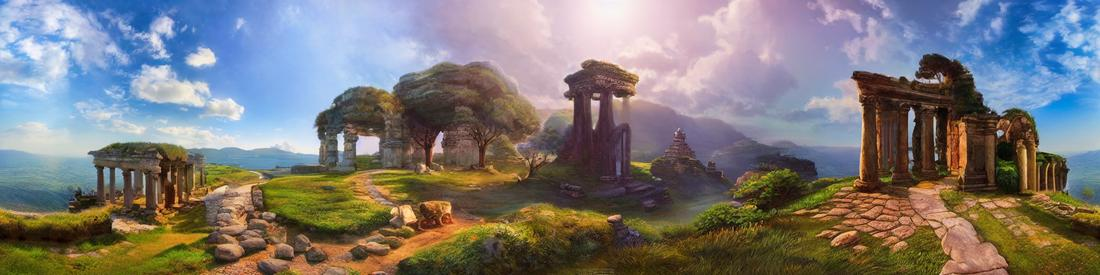

In [15]:
candidates = []

for i in range(NUM_CANDIDATES):
    seed = BASE_SEED + i
    print(f"[{i + 1}/{NUM_CANDIDATES}] {'+'.join(SELECTED_THEMES)}  seed={seed}")
    result = render_world(SELECTED_THEMES, PANORAMA_WIDTH, PANORAMA_HEIGHT, seed)
    path = OUTPUT_DIR / f"{RUN_TAG}_seed{seed}.png"
    result["image"].save(path)
    result["path"] = str(path)
    candidates.append(result)
    print(f"    {result['seconds']:.0f}s   seam ratio {result['seam_ratio']}   "
          f"saved {path.name}")
    display(preview(result["image"]))

## Step 8: Does it actually loop?

The claim is that the panorama is a cylinder, not a strip. Two checks:

1. **Roll it.** Shifting the image sideways by half its width moves whatever was
   at the left/right join into the middle of the frame, where a seam would be
   impossible to miss. Roll by a quarter too — a seam has nowhere to hide.
2. **Measure it.** `seam_ratio` compares the first-to-last-column difference
   against the average neighbouring-column difference. Around 1 means the join
   is statistically indistinguishable from any other pair of columns. Step 10
   runs the same measurement with circular sampling turned off, so the number
   below has something to be compared against.

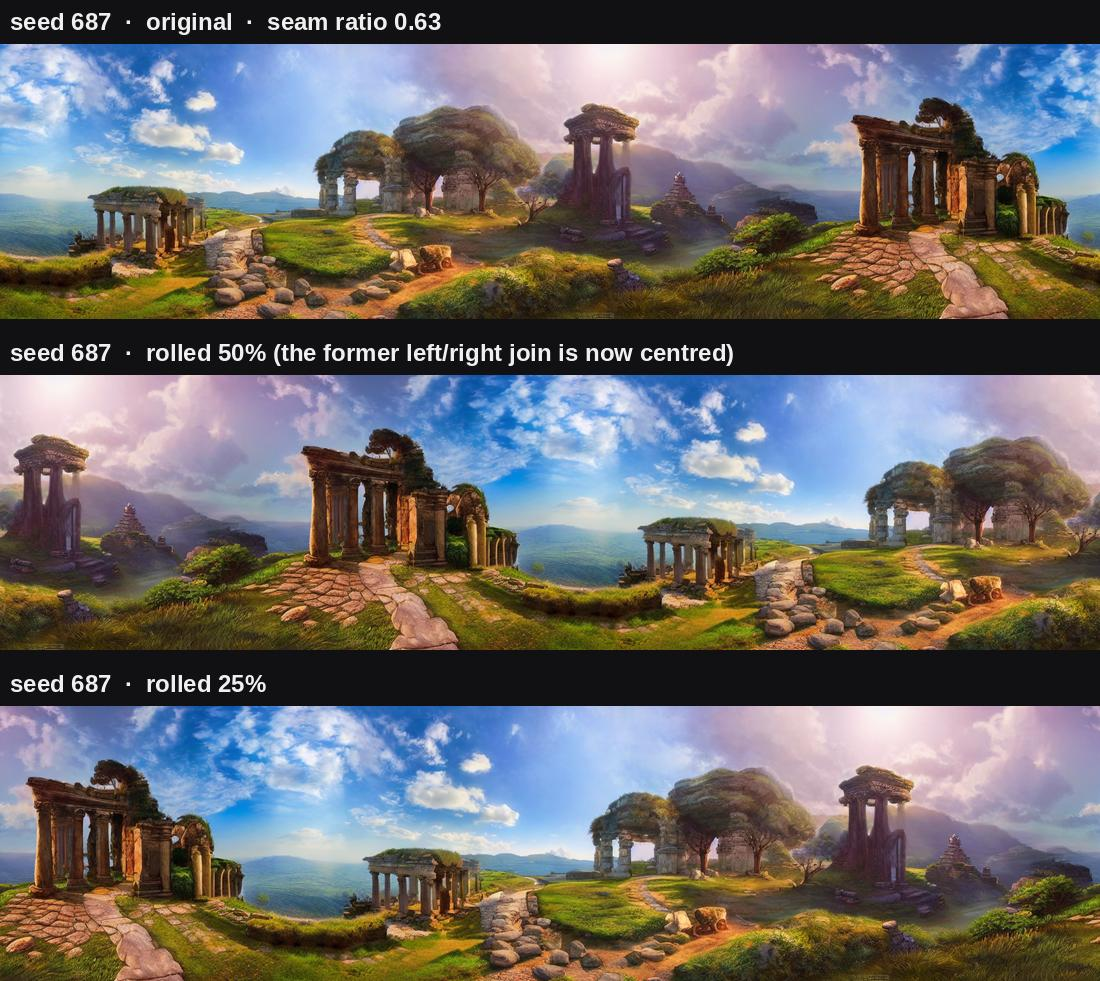


seam ratio (1.0 == the loop is as smooth as any other column pair)
  seed 687: 0.63


In [16]:
panels = []
for result in candidates:
    img = result["image"]
    a = np.asarray(img)
    quarter = Image.fromarray(np.roll(a, a.shape[1] // 4, axis=1))
    panels.append(captioned(preview(img),
                            f"seed {result['seed']}  ·  original  ·  "
                            f"seam ratio {result['seam_ratio']}"))
    panels.append(captioned(preview(roll_half(img)),
                            f"seed {result['seed']}  ·  rolled 50% "
                            f"(the former left/right join is now centred)"))
    panels.append(captioned(preview(quarter),
                            f"seed {result['seed']}  ·  rolled 25%"))

seam_figure = stack(panels)
seam_figure.save(OUTPUT_DIR / f"{RUN_TAG}_seamcheck.png")
display(seam_figure)
print("\nseam ratio (1.0 == the loop is as smooth as any other column pair)")
for result in candidates:
    print(f"  seed {result['seed']}: {result['seam_ratio']:.2f}")

## Step 9: Pick the best candidate

Two numbers per candidate, neither of them a matter of taste:

- **CLIP score** — how well the image matches the theme description, using
  CLIP ViT-L/14. This is the *only* other pretrained weight in the notebook and
  it is used strictly as a judge of finished images; it generates nothing. That
  is the "pretrained reward model used for guidance" case the project rules
  allow. Set `USE_CLIP_RANKING = False` to skip it — the notebook still runs.
- **Seam ratio** — from Step 8. A candidate with a visible seam is disqualified
  no matter how pretty it is.

Because a panorama is 4x wider than CLIP's square input, each candidate is
scored on several 512x512 crops taken around the loop, and the score for a theme
is the **best** crop (does this theme appear convincingly *somewhere*?). With
two themes the final score is the **worst** of the two theme scores, which
penalises a candidate that quietly dropped one of them.

Scoring model (judge only, generates nothing): openai/clip-vit-large-patch14

  seed    seam     CLIP  per-theme
----------------------------------
   687    0.63   0.2221  {'ancient_greek_ruins': 0.297, 'storybook_watercolor_world': 0.2221}

Automatic pick: seed 687
(override by hand if you prefer another one: best = candidates[i])


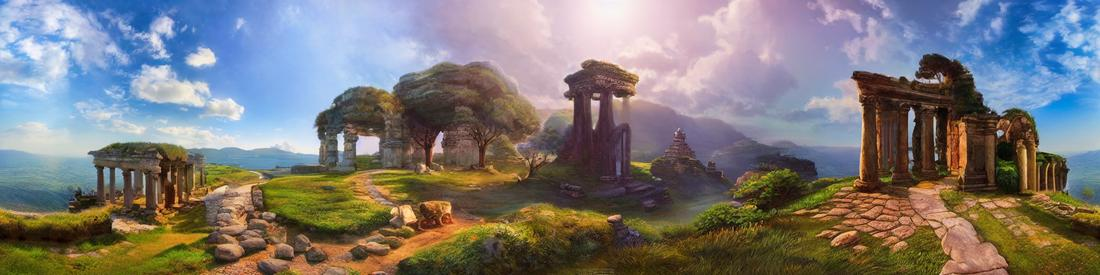

In [17]:
USE_CLIP_RANKING = True
CLIP_MODEL_ID = "openai/clip-vit-large-patch14"   # judge only -- generates nothing
SEAM_LIMIT = 4.0                                  # above this, reject outright


def square_crops(img, n=6):
    """n square crops taken evenly around the loop (wrapping past the edge)."""
    a = np.asarray(img.convert("RGB"))
    h, w = a.shape[:2]
    side = min(h, w)
    doubled = np.concatenate([a, a], axis=1)
    xs = np.linspace(0, w, n, endpoint=False).astype(int)
    return [Image.fromarray(doubled[:side, x:x + side]) for x in xs]


clip_scores = None
if USE_CLIP_RANKING:
    try:
        from transformers import CLIPModel, CLIPProcessor
        clip_model = CLIPModel.from_pretrained(CLIP_MODEL_ID).to(DEVICE).eval()
        clip_proc = CLIPProcessor.from_pretrained(CLIP_MODEL_ID)
        print(f"Scoring model (judge only, generates nothing): {CLIP_MODEL_ID}")

        @torch.no_grad()
        def score_against_themes(img, themes):
            texts = [THEME_PROMPTS[t] for t in themes]
            crops = square_crops(img)
            inputs = clip_proc(text=texts, images=crops, return_tensors="pt",
                               padding=True, truncation=True).to(DEVICE)
            out = clip_model(**inputs)
            sim = out.logits_per_image / clip_model.logit_scale.exp()  # cosine
            per_theme = sim.max(dim=0).values                          # best crop
            return float(per_theme.min()), [round(float(v), 4) for v in per_theme]

        clip_scores = {}
        for result in candidates:
            combined, per_theme = score_against_themes(result["image"],
                                                       SELECTED_THEMES)
            result["clip_score"] = round(combined, 4)
            result["clip_score_per_theme"] = dict(zip(SELECTED_THEMES, per_theme))
            clip_scores[result["seed"]] = combined
        del clip_model, clip_proc
        gc.collect()
        if DEVICE == "cuda":
            torch.cuda.empty_cache()
    except Exception as exc:                                # noqa: BLE001
        print(f"CLIP ranking unavailable ({type(exc).__name__}: {exc}); "
              "falling back to seam ratio only.")
        clip_scores = None

header = f"{'seed':>6} {'seam':>7} {'CLIP':>8}  per-theme"
print("\n" + header)
print("-" * len(header))
for result in candidates:
    clip_txt = f"{result.get('clip_score', float('nan')):8.4f}" if clip_scores \
        else f"{'--':>8}"
    print(f"{result['seed']:>6} {result['seam_ratio']:>7.2f} {clip_txt}  "
          f"{result.get('clip_score_per_theme', '')}")

usable = [r for r in candidates if r["seam_ratio"] <= SEAM_LIMIT] or candidates
best = max(usable, key=lambda r: r.get("clip_score", -r["seam_ratio"]))
print(f"\nAutomatic pick: seed {best['seed']}")
print("(override by hand if you prefer another one: best = candidates[i])")
display(preview(best["image"]))

## Step 10: Controls

Three questions the results above cannot answer on their own. Each costs one
extra generation, so they are behind flags — but they are what turns "it looks
seamless" into evidence, and they are the material for the write-up's analysis
section.

1. **Is `circular` doing anything?** Same theme, same seed, same everything,
   with the window wrapping disabled. If the seam ratio does not move, the
   circular machinery was decoration.
2. **Is region conditioning better than one fused prompt?** (Two themes only.)
   The fused prompt is the obvious approach and it is what Step 4 showed
   overflows CLIP's context. This renders both and puts them side by side.
3. **Does the stride shortcut cost anything?** `VIEW_STRIDE = 16` halves the
   work versus the reference implementation's hard-coded 8. This renders the
   same seed at stride 8 to see whether the difference is visible.

These run at reduced settings by default so the controls stay cheap relative to
the real renders.

Control 1: circular window wrapping OFF
    step  10/30     12s
    step  20/30     25s
    step  30/30     38s
           circular window wrapping ON (same seed)
    step  10/30     19s
    step  20/30     37s
    step  30/30     55s


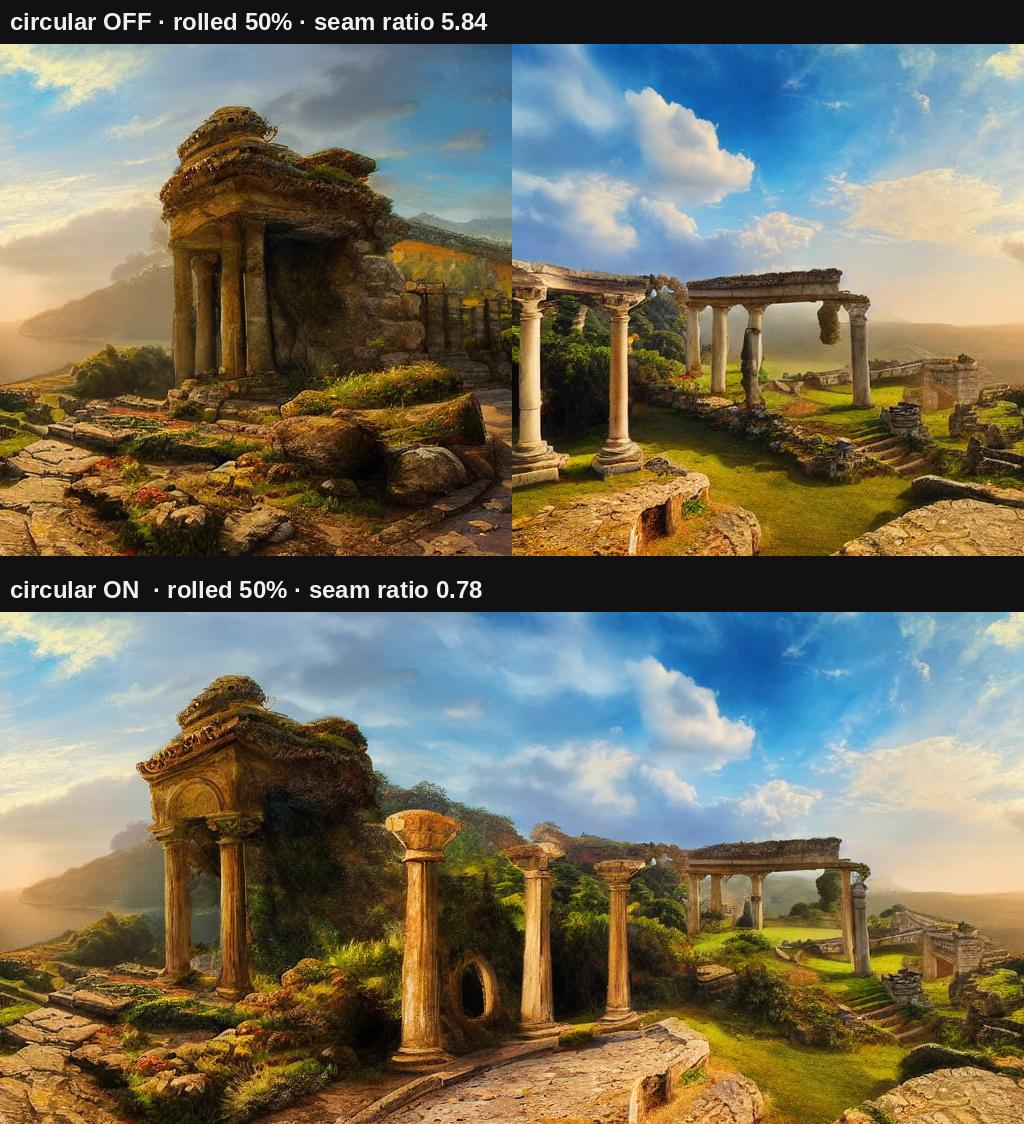

  seam ratio  OFF 5.84   ON 0.78   (7.5x worse without it)

Control 2: the four ways of combining two themes, same seed
  single_prompt
  !! 87 tokens -> truncated to 77: 'a single unified landscape that seamlessly blends together t...'
  blend
  regions
  compose


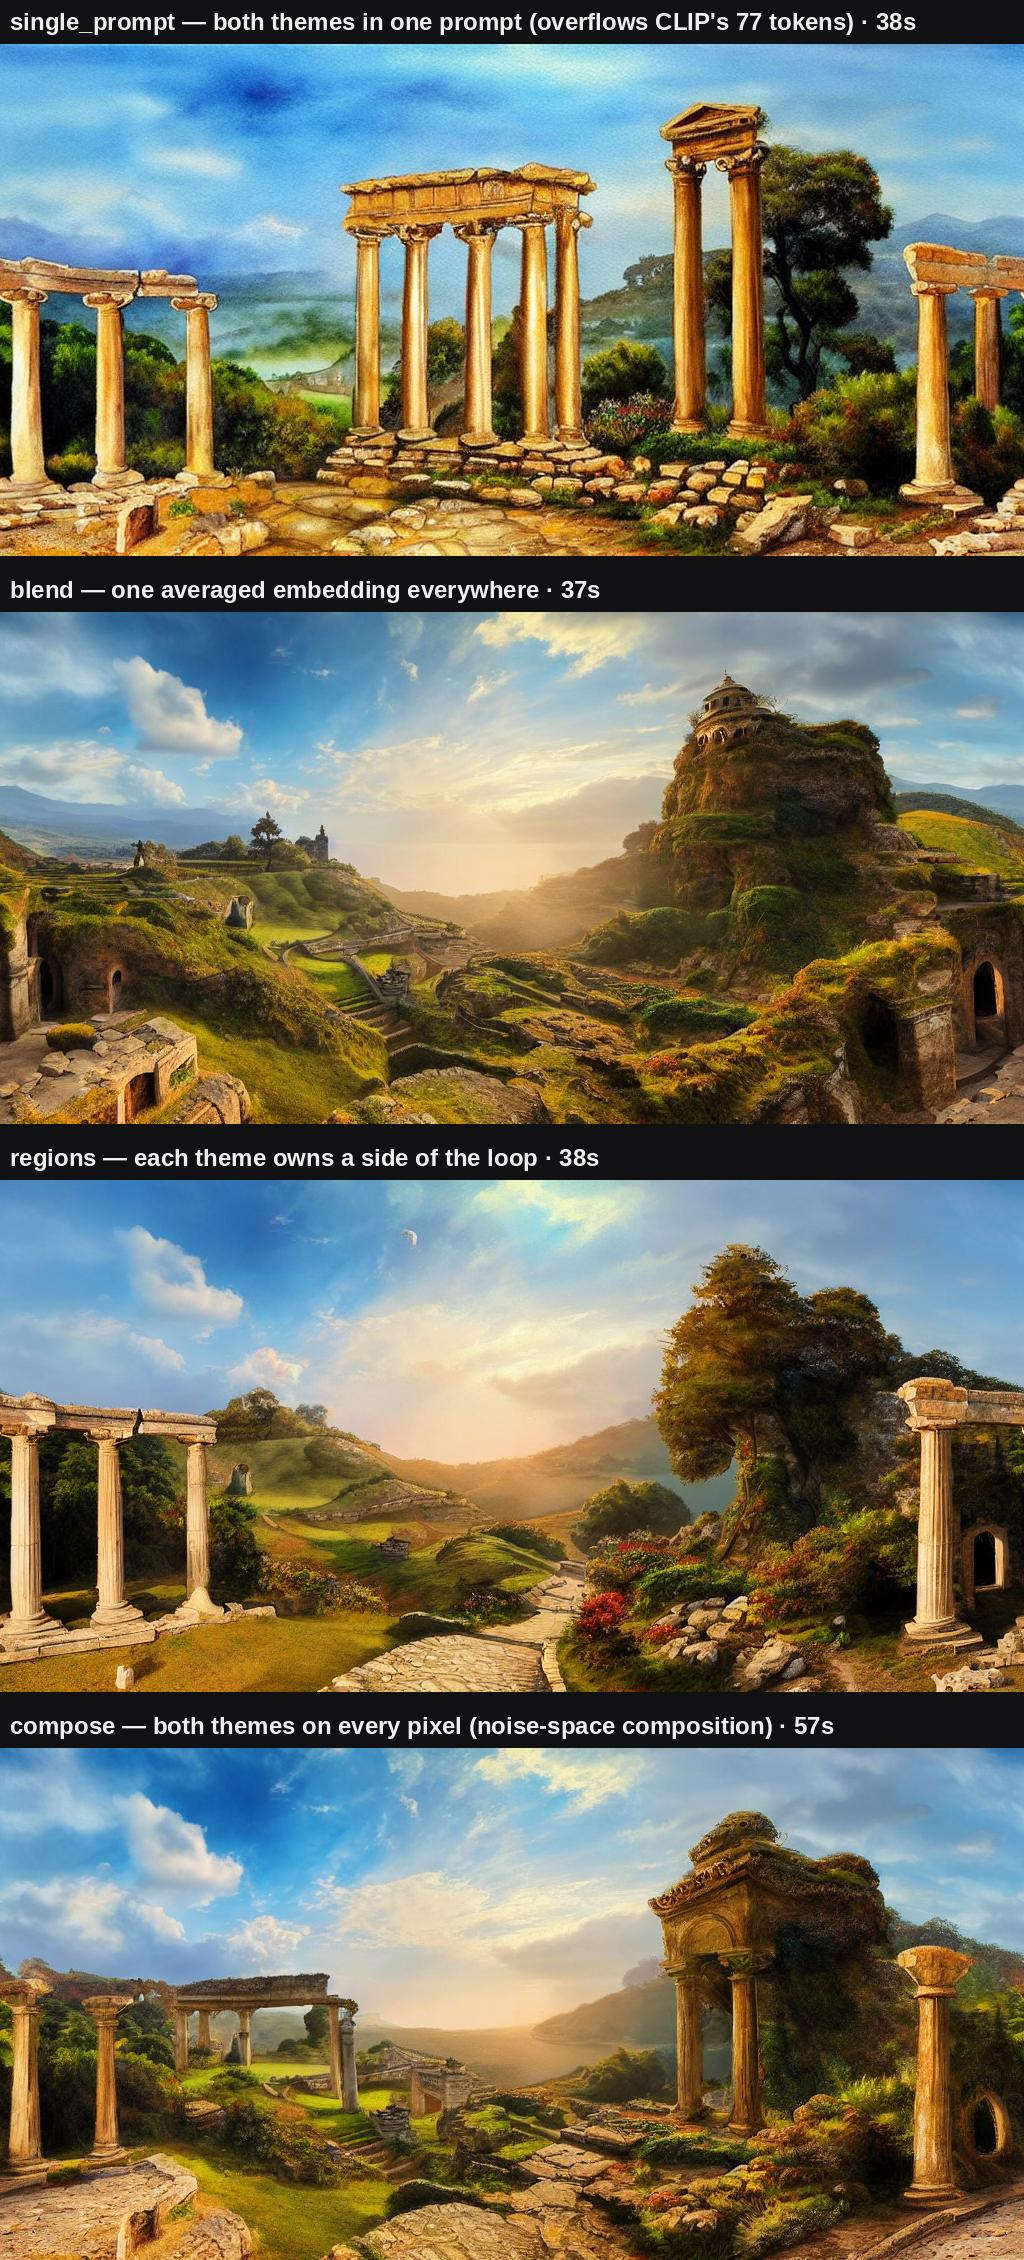

In [18]:
# These read `best` from Step 9 when it exists, so the controls describe the
# image you actually chose -- but they fall back to BASE_SEED, which means this
# whole section can be run on its own, straight after Step 6, to decide
# FUSION_MODE before spending time on a full NUM_CANDIDATES run.
control_seed = best["seed"] if "best" in globals() else BASE_SEED

RUN_CIRCULAR_CONTROL = True     # ~1 render
RUN_FUSION_CONTROL   = True     # ~1 render, only meaningful with 2 themes
RUN_STRIDE_CONTROL   = False    # ~2x one render -- the slowest of the three

CONTROL_WIDTH  = 1024           # cheaper canvas for the controls
CONTROL_STEPS  = 30
controls = []

if RUN_CIRCULAR_CONTROL:
    print("Control 1: circular window wrapping OFF")
    off = render_world(SELECTED_THEMES, CONTROL_WIDTH, PANORAMA_HEIGHT,
                       control_seed, steps=CONTROL_STEPS, circular=False)
    print("           circular window wrapping ON (same seed)")
    on = render_world(SELECTED_THEMES, CONTROL_WIDTH, PANORAMA_HEIGHT,
                      control_seed, steps=CONTROL_STEPS, circular=True)
    controls += [("circular_off", off), ("circular_on", on)]
    figure = stack([
        captioned(preview(roll_half(off["image"])),
                  f"circular OFF · rolled 50% · seam ratio {off['seam_ratio']:.2f}"),
        captioned(preview(roll_half(on["image"])),
                  f"circular ON  · rolled 50% · seam ratio {on['seam_ratio']:.2f}"),
    ])
    figure.save(OUTPUT_DIR / f"{RUN_TAG}_control_circular.png")
    display(figure)
    print(f"  seam ratio  OFF {off['seam_ratio']:.2f}   ON {on['seam_ratio']:.2f}"
          f"   ({off['seam_ratio'] / max(on['seam_ratio'], 1e-6):.1f}x worse "
          f"without it)")

if RUN_FUSION_CONTROL and len(SELECTED_THEMES) == 2:
    print("\nControl 2: the four ways of combining two themes, same seed")
    labels = {
        "single_prompt": "both themes in one prompt (overflows CLIP's 77 tokens)",
        "blend":         "one averaged embedding everywhere",
        "regions":       "each theme owns a side of the loop",
        "compose":       "both themes on every pixel (noise-space composition)",
    }
    panels = []
    for mode in ("single_prompt", "blend", "regions", "compose"):
        print(f"  {mode}")
        run = render_world(SELECTED_THEMES, CONTROL_WIDTH, PANORAMA_HEIGHT,
                           control_seed, steps=CONTROL_STEPS, fusion=mode,
                           quiet=True)
        controls.append((f"fusion_{mode}", run))
        panels.append(captioned(
            preview(run["image"]),
            f"{mode} — {labels[mode]} · {run['seconds']:.0f}s"))
    figure = stack(panels)
    figure.save(OUTPUT_DIR / f"{RUN_TAG}_control_fusion.png")
    display(figure)
elif RUN_FUSION_CONTROL:
    print("\nControl 2 skipped: only meaningful with two themes selected.")

if RUN_STRIDE_CONTROL:
    print("\nControl 3: window stride 16 vs 8")
    coarse = render_world(SELECTED_THEMES, CONTROL_WIDTH, PANORAMA_HEIGHT,
                          control_seed, steps=CONTROL_STEPS, stride=16)
    fine = render_world(SELECTED_THEMES, CONTROL_WIDTH, PANORAMA_HEIGHT,
                        control_seed, steps=CONTROL_STEPS, stride=8)
    controls += [("stride_16", coarse), ("stride_8", fine)]
    figure = stack([
        captioned(preview(coarse["image"]),
                  f"stride 16 · {coarse['num_views']} windows · "
                  f"{coarse['seconds']:.0f}s · seam {coarse['seam_ratio']:.2f}"),
        captioned(preview(fine["image"]),
                  f"stride 8 · {fine['num_views']} windows · "
                  f"{fine['seconds']:.0f}s · seam {fine['seam_ratio']:.2f}"),
    ])
    figure.save(OUTPUT_DIR / f"{RUN_TAG}_control_stride.png")
    display(figure)

### Cross-check against the reference implementation

`diffusers` ships its own MultiDiffusion sampler
(`StableDiffusionPanoramaPipeline`). The sampler in Step 5 was written from
scratch, so this cell runs the reference on the same checkpoint and settings as
an independent check that the re-implementation behaves like the published
method. It is a *correctness* check, not a source of any submitted image, and it
is skipped automatically when the deprecated pipeline is absent.

**The reference only works one window-row tall.** Its circular-padding branch
scatters each finished window back into the canvas like this:

```python
value[:, :, h_start:h_end, w_start:] += latents_view_denoised[:, :, h_start:h_end, ...]
```

`latents_view_denoised` is a single 64-latent-tall window, but it is being
sliced by the *canvas* row range — correct only while `h_start == 0`. On a
canvas taller than 512 px the second row of windows asks a 64-tall tensor for
rows 8:72, gets 56, and the pipeline dies with a shape mismatch. (The
non-circular branch a few lines below uses the whole window and is fine, so this
only bites `circular_padding=True`.) The pipeline is deprecated and unmaintained
past diffusers 0.33.1, so it will not be fixed.

The cross-check therefore runs at `REFERENCE_HEIGHT = 512` no matter how tall
your canvas is. One row of windows is enough to check the sampler against the
published method, which is all this cell is for. The sampler in Step 5 has no
such limit — it scatters with wrapped column indices and never indexes a window
by canvas coordinates, which is why every taller panorama in this notebook works.

The two images will not be pixel-identical — different initial-noise plumbing —
but a correct re-implementation produces the same kind of picture with the same
seamlessness.

The StableDiffusionPanoramaPipeline has been deprecated and will not receive bug fixes or feature updates after Diffusers version 0.33.1. 


Reference StableDiffusionPanoramaPipeline · ancient_greek_ruins · 1024x512 · 30 steps
    step  10/30     24s
    step  20/30     49s
    step  30/30     73s


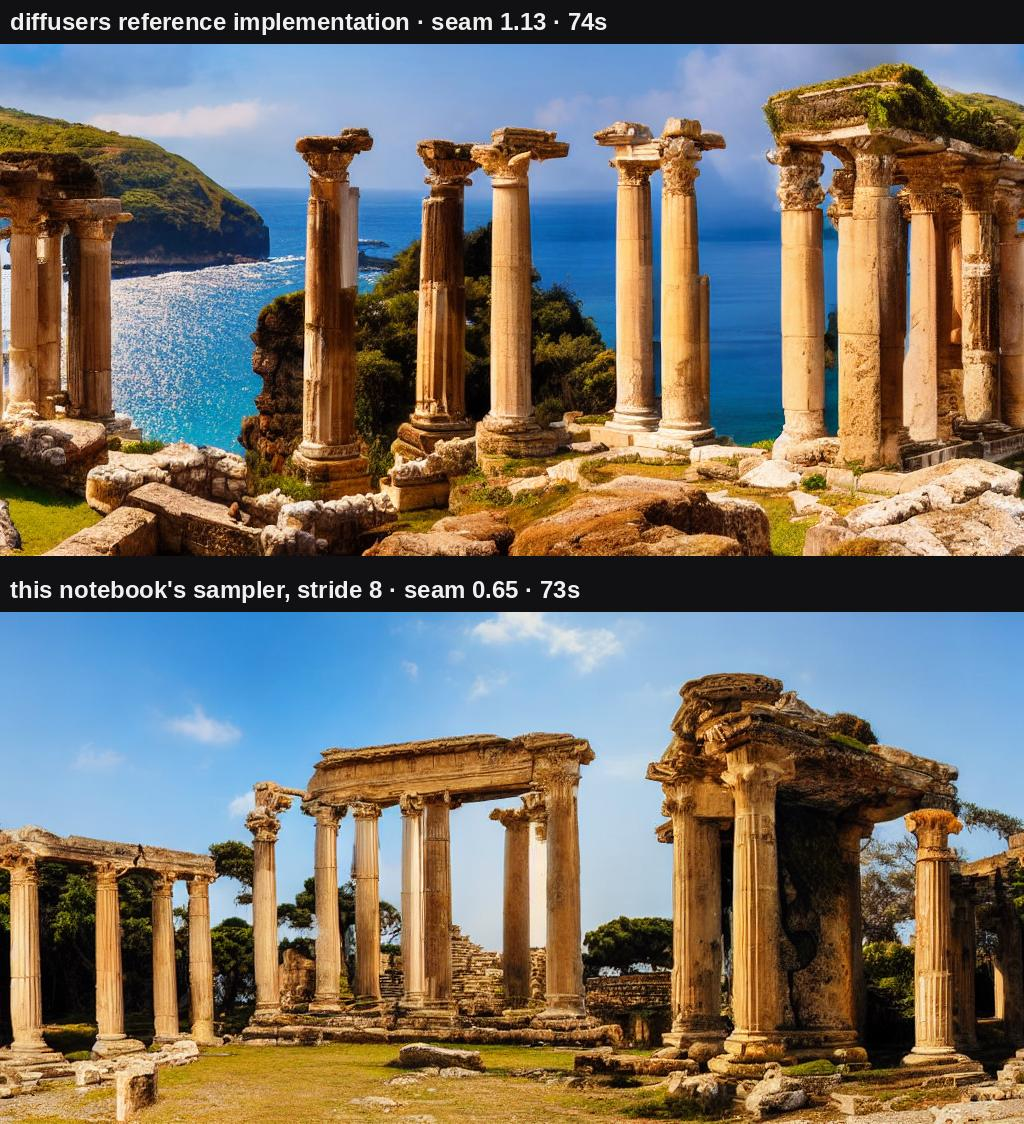


seam ratio  reference 1.13  vs  ours 0.65


In [19]:
RUN_REFERENCE_CHECK = True
REFERENCE_HEIGHT = 512   # the only canvas height the deprecated reference
                         # supports with circular_padding -- see the note above

if RUN_REFERENCE_CHECK and REFERENCE_PIPELINE_AVAILABLE:
    reference = StableDiffusionPanoramaPipeline(
        vae=pipe.vae, text_encoder=pipe.text_encoder, tokenizer=pipe.tokenizer,
        unet=pipe.unet, scheduler=pipe.scheduler, safety_checker=None,
        feature_extractor=None, requires_safety_checker=False,
    )
    reference.set_progress_bar_config(disable=True)
    theme = SELECTED_THEMES[0]
    print(f"Reference StableDiffusionPanoramaPipeline · {theme} · "
          f"{CONTROL_WIDTH}x{REFERENCE_HEIGHT} · {CONTROL_STEPS} steps")
    if REFERENCE_HEIGHT != PANORAMA_HEIGHT:
        print(f"  (run at {REFERENCE_HEIGHT}px, not your {PANORAMA_HEIGHT}px canvas: "
              f"the reference cannot do multi-row circular padding)")
    try:
        t0 = time.time()
        reference_image = reference(
            f"{THEME_PROMPTS[theme]}, {QUALITY_SUFFIX}",
            negative_prompt=NEGATIVE_PROMPT,
            width=CONTROL_WIDTH, height=REFERENCE_HEIGHT,
            num_inference_steps=CONTROL_STEPS,
            guidance_scale=GUIDANCE_SCALE,
            circular_padding=True,
            view_batch_size=VIEW_BATCH_SIZE,
            generator=torch.Generator(device=DEVICE).manual_seed(control_seed),
        ).images[0]
        reference_seconds = time.time() - t0
        reference_seam = seam_ratio(reference_image)

        # Same canvas, same seed, same stride as the reference's hard-coded 8.
        mine = render_world([theme], CONTROL_WIDTH, REFERENCE_HEIGHT, control_seed,
                            steps=CONTROL_STEPS, stride=8)
        figure = stack([
            captioned(preview(reference_image),
                      f"diffusers reference implementation · "
                      f"seam {reference_seam:.2f} · {reference_seconds:.0f}s"),
            captioned(preview(mine["image"]),
                      f"this notebook's sampler, stride 8 · "
                      f"seam {mine['seam_ratio']:.2f} · {mine['seconds']:.0f}s"),
        ])
        figure.save(OUTPUT_DIR / f"{RUN_TAG}_control_reference.png")
        display(figure)
        print(f"\nseam ratio  reference {reference_seam:.2f}  vs  "
              f"ours {mine['seam_ratio']:.2f}")
    except Exception as exc:  # noqa: BLE001
        # Nothing in a deprecated, unmaintained cross-check is worth losing the
        # session over -- newer diffusers builds may fail it in new ways.
        print(f"Reference pipeline failed ({type(exc).__name__}: {exc}). Skipping -- "
              "this affects only the cross-check, not any generated panorama.")
    finally:
        del reference
        gc.collect()
        if DEVICE == "cuda":
            torch.cuda.empty_cache()
elif RUN_REFERENCE_CHECK:
    print("Reference pipeline not available in this diffusers build -- skipped.")

## Step 11: Contact sheet and run metadata

One labelled sheet of everything this run produced, and a JSON log with every
setting needed to reproduce it — checkpoint id, scheduler, resolved prompts,
negative prompt, resolution, steps, guidance, window/stride, every seed, and the
measured seam ratio and CLIP score per candidate. Same idea as the
`dreambooth_metadata.json` the course example writes, adapted to what actually
varies here.

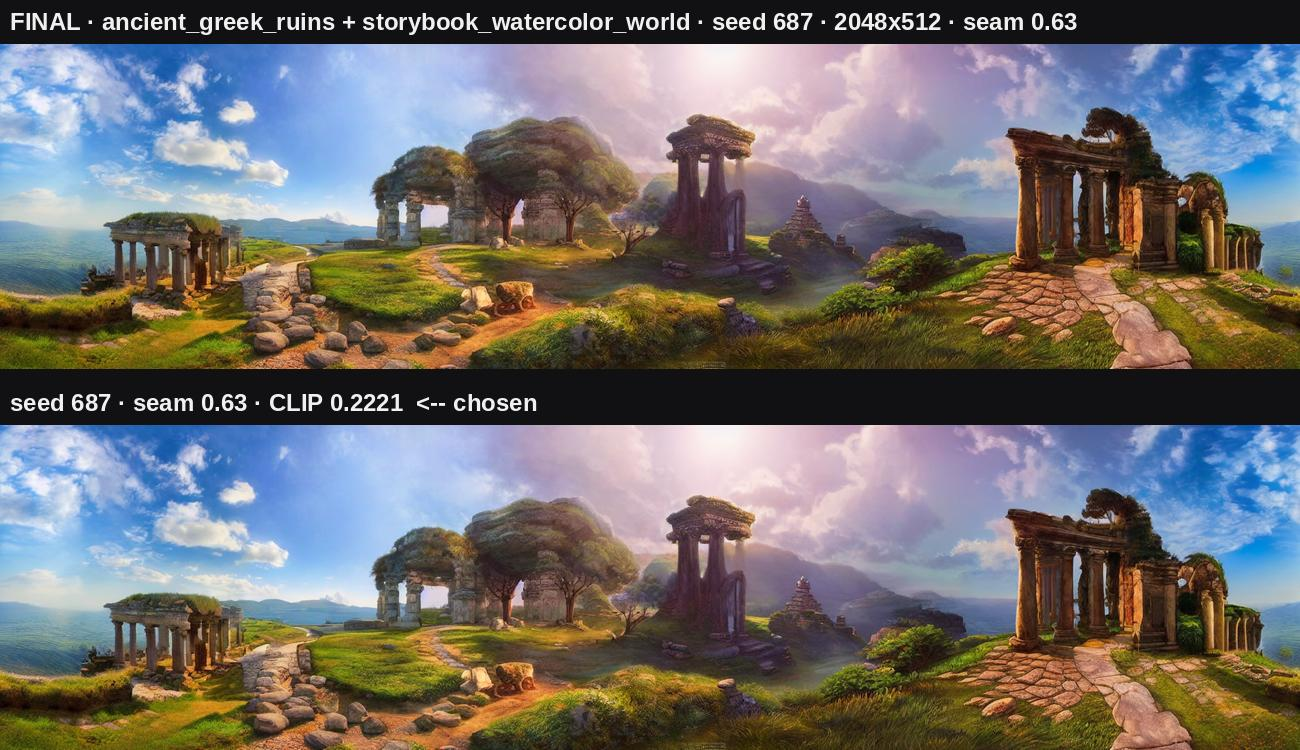

Saved ancient_greek_ruins+storybook_watercolor_world_0910-1402_contactsheet.png


In [20]:
sheet_panels = [captioned(
    preview(best["image"], 1300),
    f"FINAL · {' + '.join(SELECTED_THEMES)} · seed {best['seed']} · "
    f"{PANORAMA_WIDTH}x{PANORAMA_HEIGHT} · seam {best['seam_ratio']:.2f}")]
for result in candidates:
    mark = "  <-- chosen" if result is best else ""
    sheet_panels.append(captioned(
        preview(result["image"], 1300),
        f"seed {result['seed']} · seam {result['seam_ratio']:.2f} · "
        f"CLIP {result.get('clip_score', float('nan')):.4f}{mark}"))
contact_sheet = stack(sheet_panels)
sheet_path = OUTPUT_DIR / f"{RUN_TAG}_contactsheet.png"
contact_sheet.save(sheet_path)
display(contact_sheet)
print(f"Saved {sheet_path.name}")

In [21]:
def strip_image(record):
    return {k: v for k, v in record.items() if k != "image"}


metadata = {
    "project": "Theme Worlds -- seamless wrap-around panoramas with MultiDiffusion",
    "author": "Marlen Melis",
    "run_tag": RUN_TAG,
    "timestamp": datetime.now().isoformat(timespec="seconds"),
    "generative_checkpoint": MODEL_ID,
    "auxiliary_weights": (
        {"id": CLIP_MODEL_ID, "role": "scores finished images only, generates nothing"}
        if clip_scores else None
    ),
    "source_images_used": 0,
    "training_performed": False,
    "method": {
        "sampler": "MultiDiffusion (Bar-Tal et al., 2023), re-implemented in Step 5",
        "circular_windows": True,
        "region_conditioned": len(SELECTED_THEMES) > 1,
        "window_px": WINDOW * VAE_SCALE,
        "view_stride_latent": VIEW_STRIDE,
        "view_batch_size": VIEW_BATCH_SIZE,
        "fusion_mode": FUSION_MODE if len(SELECTED_THEMES) > 1 else "single_theme",
        "fusion_lambda": FUSION_LAMBDA,
        "blend_sharpness": BLEND_SHARPNESS if len(SELECTED_THEMES) > 1 else None,
    },
    "scheduler": {"class": type(pipe.scheduler).__name__,
                  **{k: v for k, v in pipe.scheduler.config.items()
                     if not k.startswith("_")}},
    "selected_themes": SELECTED_THEMES,
    "theme_prompts": {t: THEME_PROMPTS[t] for t in SELECTED_THEMES},
    "quality_suffix": QUALITY_SUFFIX,
    "negative_prompt": NEGATIVE_PROMPT,
    "resolved_prompts": candidates[0]["prompts"],
    "canvas": {"width": PANORAMA_WIDTH, "height": PANORAMA_HEIGHT},
    "sampling": {"steps": NUM_STEPS, "guidance_scale": GUIDANCE_SCALE,
                 "dtype": str(DTYPE), "device": DEVICE},
    "seeds": [r["seed"] for r in candidates],
    "chosen_seed": best["seed"],
    "candidates": [strip_image(r) for r in candidates],
    "controls": {name: strip_image(r)
                 for name, r in globals().get("controls", [])},
    "library_versions": {"diffusers": diffusers.__version__,
                         "transformers": transformers.__version__,
                         "torch": torch.__version__},
}

metadata_path = METADATA_DIR / f"{RUN_TAG}_metadata.json"
metadata_path.write_text(json.dumps(metadata, indent=2, default=str),
                         encoding="utf-8")
print(f"Saved {metadata_path}")
print(json.dumps({k: metadata[k] for k in
                  ("generative_checkpoint", "source_images_used",
                   "training_performed", "selected_themes", "seeds",
                   "chosen_seed")}, indent=2))

Saved /content/drive/MyDrive/AIC200-ThemeWorlds/metadata/ancient_greek_ruins+storybook_watercolor_world_0910-1402_metadata.json
{
  "generative_checkpoint": "stable-diffusion-v1-5/stable-diffusion-v1-5",
  "source_images_used": 0,
  "training_performed": false,
  "selected_themes": [
    "ancient_greek_ruins",
    "storybook_watercolor_world"
  ],
  "seeds": [
    687
  ],
  "chosen_seed": 687
}


## Step 12: What just happened, and what to write up

### Files in `PROJECT_DIR`

```text
MyDrive/AIC200-ThemeWorlds/
├── outputs/    every candidate at full resolution, the seam-check sheet,
│               the control figures, the contact sheet
└── metadata/   one JSON per run with everything needed to reproduce it
```

### Compliance checklist

- [x] Every generated pixel comes from `stable-diffusion-v1-5/stable-diffusion-v1-5`; the id is printed in Step 3 and logged in Step 11
- [x] No SDXL/FLUX, no third-party SD checkpoint, LoRA or DreamBooth model
- [x] The only other pretrained weight is CLIP ViT-L/14, used solely to score finished images (Step 9) — it can be turned off and the notebook still runs
- [x] Zero source or training images anywhere; no upload step exists
- [x] No training or fine-tuning
- [x] Circular window wrapping on for every submitted panorama
- [x] Every seed fixed and logged; noise drawn on the CPU generator so seeds reproduce across GPUs
- [x] All labels and composites drawn with PIL on top of finished pixels — nothing relies on SD v1.5 rendering text
- [x] Nothing edited outside this notebook
- [x] Single `.ipynb`, runs end to end on a Colab T4
- [x] Output is static PNG — no video, animation or GIF

### For the write-up

| Section | Where it comes from |
| --- | --- |
| Goal and concept | The header: one or two themes in, one seamless wrap-around world out, SD v1.5 only |
| Method | Step 5 — MultiDiffusion re-implemented, plus the two extensions: circular windows and per-region conditioning |
| Data and resources | Zero source images. SD v1.5 (link in Step 3); CLIP ViT-L/14 as a scorer only (Step 9) |
| Experimental setup | The metadata JSON from Step 11 — prompts, seeds, resolution, steps, guidance, stride, batch size |
| Results and analysis | Step 8 seam figures, the Step 10 controls, and the Step 9 score table |

The strongest analysis material is Step 10. The circular control turns
"it looks seamless" into a measured ratio against an identical run without it;
the fusion control shows what the naive concatenated prompt does instead; and
the Step 4 token count explains *why* the naive version was never going to work
— CLIP silently throws the quality suffix away at 77 tokens.

### To try another world

Change `SELECTED_THEMES` in Step 6 and re-run from Step 7. Every run writes its
own files under its own `RUN_TAG`, so nothing is overwritten and a handful of
combinations back to back becomes the depth-of-exploration evidence.

## Step 13: Take your files with you

Bundles everything this run wrote into a single zip next to the project folder.

If you mounted Drive in Step 2 the files are already safe and this is only a
convenience. If you did not, `/content` is wiped when the session ends, so the
cell hands the zip to your browser as a download — accept the prompt before you
close the tab.

In [22]:
import shutil

# Written to PROJECT_DIR's parent, not inside it -- an archive that contains
# itself grows every time you re-run the cell.
archive_base = PROJECT_DIR.parent / f"{RUN_TAG}_results"
archive = Path(shutil.make_archive(str(archive_base), "zip", root_dir=str(PROJECT_DIR)))
print(f"{archive}  ({archive.stat().st_size / 1e6:.1f} MB)")

produced = sorted(OUTPUT_DIR.glob("*.png"))
print(f"\n{len(produced)} image(s) in this project folder:")
for path in produced:
    print(f"  {path.name}")

if ON_DRIVE:
    print("\nAlready in your Google Drive, zip included -- nothing else to do.")
elif IN_COLAB:
    print("\nNot on Drive: offering the zip as a browser download (accept the prompt).")
    try:
        from google.colab import files
        files.download(str(archive))
    except Exception as exc:  # noqa: BLE001
        print(f"  download failed ({type(exc).__name__}) -- open the folder icon in "
              "the left sidebar and download it by hand.")

/content/drive/MyDrive/ancient_greek_ruins+storybook_watercolor_world_0910-1402_results.zip  (125.8 MB)

49 image(s) in this project folder:
  ancient_greek_ruins+storybook_watercolor_world_0910-1402_contactsheet.png
  ancient_greek_ruins+storybook_watercolor_world_0910-1402_control_circular.png
  ancient_greek_ruins+storybook_watercolor_world_0910-1402_control_fusion.png
  ancient_greek_ruins+storybook_watercolor_world_0910-1402_control_reference.png
  ancient_greek_ruins+storybook_watercolor_world_0910-1402_seamcheck.png
  ancient_greek_ruins+storybook_watercolor_world_0910-1402_seed687.png
  arctic_ice_cave+cozy_village_snowfall_0908-1757_contactsheet.png
  arctic_ice_cave+cozy_village_snowfall_0908-1757_control_circular.png
  arctic_ice_cave+cozy_village_snowfall_0908-1757_control_fusion.png
  arctic_ice_cave+cozy_village_snowfall_0908-1757_control_reference.png
  arctic_ice_cave+cozy_village_snowfall_0908-1757_seamcheck.png
  arctic_ice_cave+cozy_village_snowfall_0908-1757_seed100